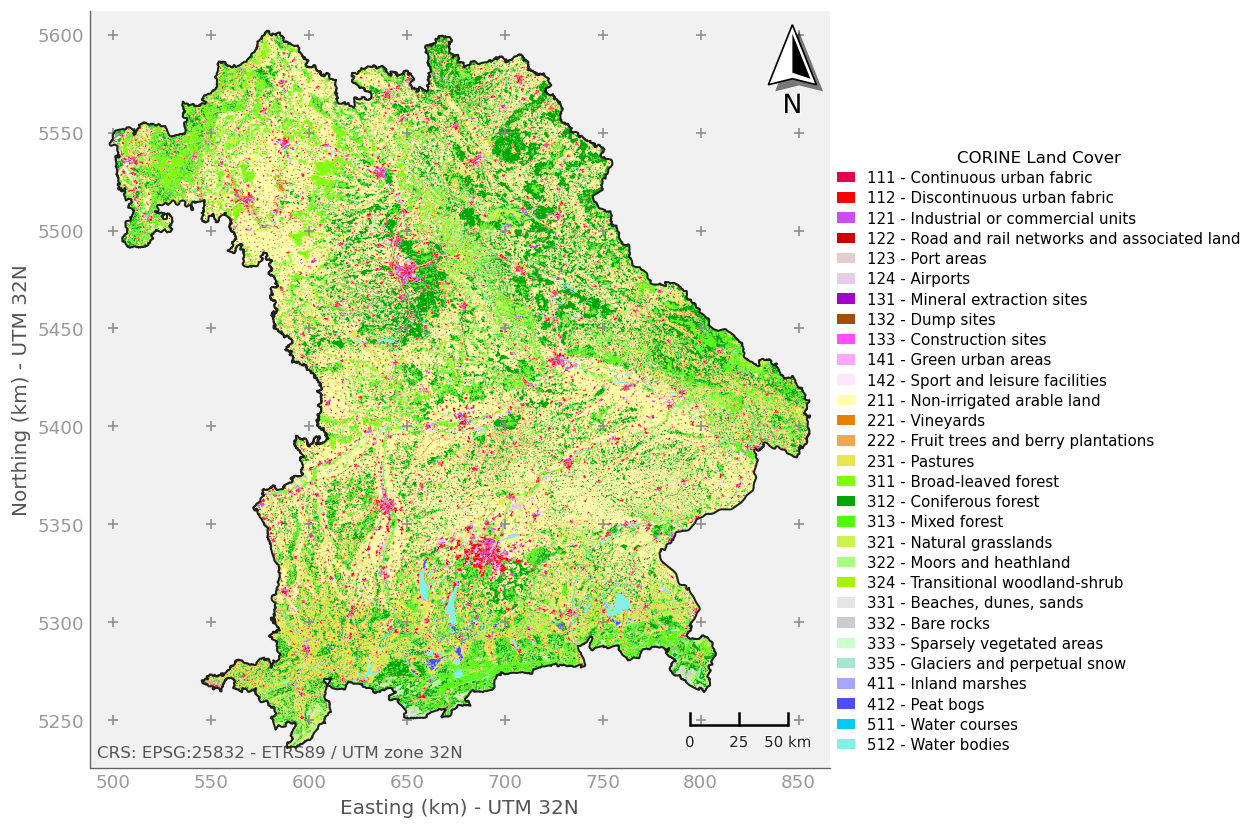

CLC polygons in Bavaria: 140081
CLC classes in map: 29
Saved map: C:\Users\agz90fk\Documents\Masterarbeit\03_Daten\Output\Figures\CLC_2012\clc_2012.jpg


In [3]:
"""
CORINE Land Cover (2012) for Bavaria.
No OSM basemap. Colors and labels are taken from CLC_legend.csv.
"""

import math
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter

try:
    from matplotlib_map_utils import north_arrow, scale_bar
    HAS_MMU = True
except Exception:
    HAS_MMU = False

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 16,
    "axes.labelsize": 12,
    "legend.fontsize": 9,
    "legend.title_fontsize": 10,
    "axes.edgecolor": "#333333",
    "axes.linewidth": 0.8,
})

# ---------------------------------------------------------------------------
# Paths and config
# ---------------------------------------------------------------------------
PATH_LANDKREISE = r"C:\Users\agz90fk\Documents\Masterarbeit\03_Daten\Input\Verwaltungsgebiete\vg250-ew_12-31.utm32s.gpkg.ebenen\vg250-ew_ebenen_1231\DE_VG250.gpkg"
LAYER_LANDKREISE = "v_vg250_krs"
PATH_CLC = r"C:\Users\agz90fk\Documents\Masterarbeit\03_Daten\Output\DatasetSpecific\CORINE_Bavaria\CORINE_Bavaria_2012.gpkg"
PATH_CLC_LEGEND = r"C:\Users\agz90fk\Documents\Masterarbeit\03_Daten\Input\CORINE_Land_Cover_DE\CLC_legend.csv"

OUTPUT_DIR = Path(r"C:\Users\agz90fk\Documents\Masterarbeit\03_Daten\Output\Figures\CLC_2012")
OUTPUT_MAP = OUTPUT_DIR / "clc_2012.jpg"

COL_ARS = "Regionalschlüssel_ARS"
BAYERN_PREFIX = "09"
TARGET_CRS = "EPSG:25832"
CRS_NOTE = "CRS: EPSG:25832 - ETRS89 / UTM zone 32N"
GRID_STEP_M = 50000
MAP_PADDING_M = 10000


def add_matplotlib_grid(ax, bounds, step=GRID_STEP_M):
    minx, miny, maxx, maxy = bounds
    x_start = math.ceil(minx / step) * step
    x_end = math.floor(maxx / step) * step
    y_start = math.ceil(miny / step) * step
    y_end = math.floor(maxy / step) * step

    x_major = [x_start + i * step for i in range(int((x_end - x_start) / step) + 1)] if x_start <= x_end else []
    y_major = [y_start + i * step for i in range(int((y_end - y_start) / step) + 1)] if y_start <= y_end else []

    ax.set_xticks(x_major)
    ax.set_yticks(y_major)
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{int(round(x / 1000))}"))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f"{int(round(y / 1000))}"))

    if x_major and y_major:
        x_pts, y_pts = [], []
        for xv in x_major:
            for yv in y_major:
                x_pts.append(xv)
                y_pts.append(yv)
        ax.scatter(x_pts, y_pts, marker="+", s=30, linewidths=1.0, color="#8a8a8a", alpha=0.95, zorder=4, clip_on=True)

    ax.tick_params(axis="both", which="major", labelsize=11, length=0, colors="#9B9999")


def add_north_arrow(ax):
    if HAS_MMU:
        north_arrow(
            ax=ax,
            location="upper right",
            size="md",
            rotation={"degrees": 0},
            aob={
                "bbox_to_anchor": (0.985, 0.985),
                "bbox_transform": ax.transAxes,
                "pad": 0.06,
                "borderpad": 0.06,
                "facecolor": "none",
                "edgecolor": "none",
                "alpha": 1.0,
                "frameon": False,
            },
        )
        return

    ax.annotate(
        "",
        xy=(0.945, 0.960),
        xytext=(0.945, 0.880),
        xycoords="axes fraction",
        textcoords="axes fraction",
        arrowprops=dict(arrowstyle="-|>", color="#222222", linewidth=1.4, shrinkA=0, shrinkB=0),
        zorder=10,
    )
    ax.text(0.945, 0.972, "N", transform=ax.transAxes, ha="center", va="bottom", fontsize=14, fontweight="bold", color="#222222", zorder=10)


def add_scale_bar(ax):
    if HAS_MMU:
        scale_bar(
            ax=ax,
            location="lower right",
            size="xs",
            style="ticks",
            bar={
                "projection": TARGET_CRS,
                "unit": "km",
                "max": 50,
                "major_div": 2,
                "minor_div": 1,
                "minor_type": "none",
                "reverse": False,
            },
            labels={"labels": ["0", "25", "50"], "style": "major", "loc": "below", "fontsize": 9},
            units={"loc": "text", "label": "km"},
            text={"fontfamily": "sans-serif", "fontsize": 9, "textcolor": "#222222"},
            aob={"pad": 0.0, "borderpad": 1.0, "facecolor": "none", "edgecolor": "none", "alpha": 1.0, "frameon": False},
        )
        return

    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()
    span_x = x1 - x0
    span_y = y1 - y0

    total_km = 50
    segment_km = 25
    bar_len = total_km * 1000
    segment_len = segment_km * 1000

    x_start = x1 - span_x * 0.35
    y_start = y0 + span_y * 0.060

    ax.plot([x_start, x_start + bar_len], [y_start, y_start], color="#222222", linewidth=1.3, zorder=8)
    tick_h = span_y * 0.006
    for x in [x_start, x_start + segment_len, x_start + bar_len]:
        ax.plot([x, x], [y_start - tick_h, y_start + tick_h], color="#222222", linewidth=1.0, zorder=8)

    txt_y = y_start + span_y * 0.011
    ax.text(x_start, txt_y, "0", ha="center", va="bottom", fontsize=9, color="#222222", zorder=8)
    ax.text(x_start + segment_len, txt_y, "25", ha="center", va="bottom", fontsize=9, color="#222222", zorder=8)
    ax.text(x_start + bar_len, txt_y, "50 km", ha="center", va="bottom", fontsize=9, color="#222222", zorder=8)


def add_scientific_frame(ax, gdf_base):
    ax.set_facecolor("#f1f1f1")
    minx, miny, maxx, maxy = gdf_base.total_bounds
    bounds = (minx - MAP_PADDING_M, miny - MAP_PADDING_M, maxx + MAP_PADDING_M, maxy + MAP_PADDING_M)
    ax.set_xlim(bounds[0], bounds[2])
    ax.set_ylim(bounds[1], bounds[3])
    ax.margins(0)
    add_matplotlib_grid(ax, bounds)

    ax.set_xlim(bounds[0], bounds[2])
    ax.set_ylim(bounds[1], bounds[3])
    ax.set_autoscale_on(False)

    ax.set_xlabel("Easting (km) - UTM 32N", fontsize=12, color="#555555")
    ax.set_ylabel("Northing (km) - UTM 32N", fontsize=12, color="#555555")
    ax.text(0.01, 0.01, CRS_NOTE, transform=ax.transAxes, ha="left", va="bottom", fontsize=10, color="#555555")

    for side in ["top", "right"]:
        ax.spines[side].set_visible(False)
    for side in ["left", "bottom"]:
        ax.spines[side].set_visible(True)
        ax.spines[side].set_color("#636262")
        ax.spines[side].set_linewidth(0.8)


def rgb_to_hex(rgb_text):
    parts = str(rgb_text).strip().replace(",", "-").split("-")
    parts = [p.strip() for p in parts if p.strip() != ""]
    if len(parts) != 3:
        return "#bdbdbd"
    try:
        r, g, b = [max(0, min(255, int(p))) for p in parts]
        return f"#{r:02x}{g:02x}{b:02x}"
    except Exception:
        return "#bdbdbd"


# ---------------------------------------------------------------------------
# Load Bavaria boundary
# ---------------------------------------------------------------------------
gdf_lk = gpd.read_file(PATH_LANDKREISE, layer=LAYER_LANDKREISE)
ars_col = COL_ARS if COL_ARS in gdf_lk.columns else next((c for c in gdf_lk.columns if "ARS" in c or "ars" in c), None)
if ars_col is None:
    raise ValueError("No ARS column found in Landkreis layer.")

gdf_lk = gdf_lk[gdf_lk[ars_col].astype(str).str.startswith(BAYERN_PREFIX)].copy()
if gdf_lk.crs is None or str(gdf_lk.crs) != TARGET_CRS:
    gdf_lk = gdf_lk.to_crs(TARGET_CRS)

gdf_bayern = gdf_lk[["geometry"]].dissolve().reset_index(drop=True)

# ---------------------------------------------------------------------------
# Load CLC and legend CSV
# ---------------------------------------------------------------------------
bbox = tuple(gdf_bayern.total_bounds)
gdf_clc = gpd.read_file(PATH_CLC, bbox=bbox)

if gdf_clc.crs is None:
    raise ValueError("CLC dataset has no CRS. Please define CRS before plotting.")
if gdf_clc.crs != gdf_bayern.crs:
    gdf_clc = gdf_clc.to_crs(gdf_bayern.crs)

gdf_clc = gdf_clc[gdf_clc.geometry.intersects(gdf_bayern.geometry.iloc[0])].copy()

legend_df = pd.read_csv(PATH_CLC_LEGEND, sep=";", dtype={"CLC_CODE": str})
legend_df["CLC_CODE"] = legend_df["CLC_CODE"].astype(str).str.strip()
legend_df["LABEL3"] = legend_df["LABEL3"].astype(str).str.strip()
legend_df["COLOR_HEX"] = legend_df["RGB"].apply(rgb_to_hex)

gdf_clc["CLC_CODE"] = gdf_clc["CLC_CODE"].astype(str).str.strip()
gdf_clc = gdf_clc.merge(
    legend_df[["CLC_CODE", "LABEL3", "COLOR_HEX"]],
    on="CLC_CODE",
    how="left",
)
gdf_clc["LABEL3"] = gdf_clc["LABEL3"].fillna("Unknown CLC class")
gdf_clc["COLOR_HEX"] = gdf_clc["COLOR_HEX"].fillna("#bdbdbd")

# ---------------------------------------------------------------------------
# Plot
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9.2, 9.8))
fig.subplots_adjust(right=0.74, left=0.07, top=0.92, bottom=0.08)

# Plot CLC polygons with per-feature colors from CSV legend
gdf_clc.plot(
    ax=ax,
    color=gdf_clc["COLOR_HEX"],
    edgecolor="none",
    linewidth=0.0,
    zorder=2,
)

# Boundary for orientation
gdf_bayern.plot(ax=ax, facecolor="none", edgecolor="#1f1f1f", linewidth=1.2, zorder=6)

# Legend: only classes present in Bavaria, labels from LABEL3
present = (
    gdf_clc[["CLC_CODE", "LABEL3", "COLOR_HEX"]]
    .drop_duplicates()
    .sort_values("CLC_CODE")
)
legend_handles = [
    Patch(facecolor=row.COLOR_HEX, edgecolor="none", label=f"{row.CLC_CODE} - {row.LABEL3}")
    for row in present.itertuples(index=False)
]
ax.legend(
    handles=legend_handles,
    title="CORINE Land Cover",
    loc="lower left",
    bbox_to_anchor=(1.01, 0.02),
    borderaxespad=0.0,
    frameon=False,
    fontsize=9,
    title_fontsize=10,
    handlelength=1.2,
    labelspacing=0.35,
    borderpad=0.0,
)
ax.get_legend().get_title().set_ha("left")

add_north_arrow(ax)
add_scale_bar(ax)
add_scientific_frame(ax, gdf_bayern)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(OUTPUT_MAP, bbox_inches="tight", facecolor="white", format="jpg")
plt.show()

print(f"CLC polygons in Bavaria: {len(gdf_clc)}")
print(f"CLC classes in map: {present['CLC_CODE'].nunique()}")
print(f"Saved map: {OUTPUT_MAP}")